In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')

In [144]:
raw_data = pd.read_csv('/Users/matiasochoa/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1/marketing_AB.csv')

raw_data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


#### EDA

In [145]:
raw_data = raw_data.iloc[:,1:]

In [146]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [147]:
raw_data['converted'] = raw_data['converted'].astype(int)
df = raw_data.copy()

In [148]:
df.describe().T.round()

,count,mean,std,min,25%,50%,75%,max
user id,588101.0,1310692.0,202226.0,900000.0,1143190.0,1313725.0,1484088.0,1654483.0
converted,588101.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
total ads,588101.0,25.0,44.0,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.0,5.0,0.0,11.0,14.0,18.0,23.0


##### The dataset is heavily skewed towards the ad group

In [149]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [150]:
df.drop(['user id','converted'], axis=1).groupby('test group').describe().T.round()

test group                 ad      psa
total ads     count  564577.0  23524.0
              mean       25.0     25.0
              std        44.0     43.0
              min         1.0      1.0
              25%         4.0      4.0
              50%        13.0     12.0
              75%        27.0     26.0
              max      2065.0    907.0
most ads hour count  564577.0  23524.0
              mean       14.0     14.0
              std         5.0      5.0
              min         0.0      0.0
              25%        11.0     11.0
              50%        14.0     14.0
              75%        18.0     18.0
              max        23.0     23.0

##### We have ads every single day of the week

In [151]:
for col in raw_data.select_dtypes(include='object'):
    print(f'{col} : {raw_data[col].unique()}')

test group : ['ad' 'psa']
most ads day : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


#### Experiments

In [152]:
# Test Group Analysis
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

t_stat, p_val = stats.ttest_ind(test_group['converted'], control_group['converted'])
print(f"Test Group Analysis - T-statistic: {t_stat:,.6f}, P-value: {p_val:,.6f}")
print('')

if p_val < 0.05:
    print("Reject the null hypothesis:\n Therefore, there is a significant difference in conversion rates between the 'ad' and 'psa' groups.")
else:
    print("Fail to reject the null hypothesis: Therefore, there is no significant difference in conversion rates between the 'ad' and 'psa' groups.")

Test Group Analysis - T-statistic: 7.370406, P-value: 0.000000

Reject the null hypothesis:
 Therefore, there is a significant difference in conversion rates between the 'ad' and 'psa' groups.


In [153]:
# Most Ads Day Analysis
anova_result_day = stats.f_oneway(
    df[df['most ads day'] == 'Monday']['converted'],
    df[df['most ads day'] == 'Tuesday']['converted'],
    df[df['most ads day'] == 'Wednesday']['converted'],
    df[df['most ads day'] == 'Thursday']['converted'],
    df[df['most ads day'] == 'Friday']['converted'],
    df[df['most ads day'] == 'Saturday']['converted'],
    df[df['most ads day'] == 'Sunday']['converted']
)
print(f"Most Ads Day Analysis - F-statistic: {anova_result_day.statistic:,.6f}, P-value: {anova_result_day.pvalue:,.6f}")

print('')

if anova_result_day.pvalue < 0.05:
    print("Reject the null hypothesis:\n\n Therefore, the day with the most ads seen significantly affects the conversion rate.")
else:
    print("Fail to reject the null hypothesis:\n\n Therefore, the day with the most ads seen does not significantly affect conversion rates.")

Most Ads Day Analysis - F-statistic: 68.388184, P-value: 0.000000

Reject the null hypothesis:

 Therefore, the day with the most ads seen significantly affects the conversion rate.


In [154]:
# Pearson correlation between total_ads and converted
pearson_corr, pearson_p_value = pearsonr(df['total ads'], df['converted'])

# Spearman correlation between total_ads and converted (non-parametric)
spearman_corr, spearman_p_value = spearmanr(df['total ads'], df['converted'])

print(f"Pearson Correlation: {pearson_corr:.4f}, p-value: {pearson_p_value:.6f}")
print(f"Spearman Correlation: {spearman_corr:.4f}, p-value: {spearman_p_value:.6f}")

Pearson Correlation: 0.2174, p-value: 0.000000
Spearman Correlation: 0.1927, p-value: 0.000000


The positive correlation is weak between the number of ads shown and the likelihood of conversion, suggesting that, in general, as the number of ads increases, the likelihood of conversion increases slightly.

Therefore, other factors might be influencing conversion as well.

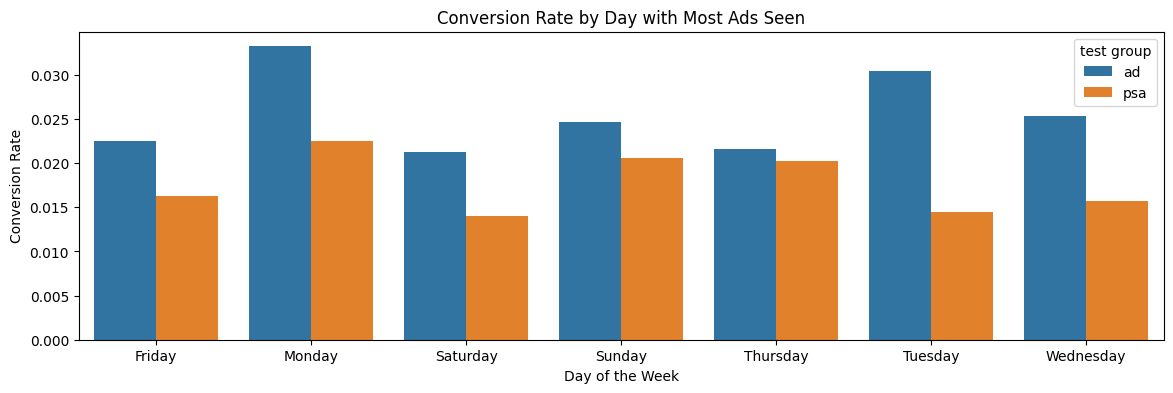

In [155]:
day_conversion_rate = (
    df.groupby(['most ads day', 'test group'])['converted']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 4))
sns.barplot(
    data=day_conversion_rate,
    x='most ads day',
    y='converted',
    hue='test group'
)

plt.title('Conversion Rate by Day with Most Ads Seen')
plt.xlabel('Day of the Week')
plt.ylabel('Conversion Rate')
plt.show()


In [156]:
# Tukey's HSD Test
tukey = pairwise_tukeyhsd(endog=df['total ads'],  # The dependent variable
                          groups=df['most ads day'],  # The grouping variable
                          alpha=0.05)  # Significance level

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
  Friday    Monday  -1.2836    0.0 -1.8919 -0.6754   True
  Friday  Saturday  -1.3845    0.0  -2.003 -0.7659   True
  Friday    Sunday  -2.2085    0.0 -2.8198 -1.5971   True
  Friday  Thursday  -3.1833    0.0 -3.7992 -2.5673   True
  Friday   Tuesday  -2.6867    0.0  -3.314 -2.0593   True
  Friday Wednesday  -2.0729    0.0  -2.693 -1.4528   True
  Monday  Saturday  -0.1009 0.9992 -0.7286  0.5268  False
  Monday    Sunday  -0.9249 0.0002 -1.5454 -0.3043   True
  Monday  Thursday  -1.8997    0.0 -2.5248 -1.2746   True
  Monday   Tuesday  -1.4031    0.0 -2.0394 -0.7667   True
  Monday Wednesday  -0.7893 0.0041 -1.4185 -0.1601   True
Saturday    Sunday   -0.824 0.0023 -1.4547 -0.1933   True
Saturday  Thursday  -1.7988    0.0  -2.434 -1.1637   True
Saturday   Tuesday  -1.3022    0.0 -1.9484  -0.656   True
Saturday Wedne

This table shows the difference in the mean values of total ads seen. mean difference = mean(group1) − mean(group2)

Friday is significantly different from all other days (Monday, Saturday, Sunday, Thursday, Tuesday, and Wednesday). In all these cases, the p-value is 0.0 (indicating strong significance).

**Non-Significant Differences (p-adj > 0.05):**

- Monday vs. Saturday (p-adj = 0.9992)
- Sunday vs. Tuesday (p-adj = 0.2925)
- Sunday vs. Wednesday (p-adj = 0.9958)
- Thursday vs. Tuesday (p-adj = 0.2564)
- Tuesday vs. Wednesday (p-adj = 0.0768)


In [157]:
# Most Ads Hour Analysis
anova_result_hour = stats.f_oneway(
    df[df['most ads hour'] == 0]['converted'],
    df[df['most ads hour'] == 1]['converted'],
    df[df['most ads hour'] == 2]['converted'],
    df[df['most ads hour'] == 3]['converted'],
    df[df['most ads hour'] == 4]['converted'],
    df[df['most ads hour'] == 5]['converted'],
    df[df['most ads hour'] == 6]['converted'],
    df[df['most ads hour'] == 7]['converted'],
    df[df['most ads hour'] == 8]['converted'],
    df[df['most ads hour'] == 9]['converted'],
    df[df['most ads hour'] == 10]['converted'],
    df[df['most ads hour'] == 11]['converted'],
    df[df['most ads hour'] == 12]['converted'],
    df[df['most ads hour'] == 13]['converted'],
    df[df['most ads hour'] == 14]['converted'],
    df[df['most ads hour'] == 15]['converted'],
    df[df['most ads hour'] == 16]['converted'],
    df[df['most ads hour'] == 17]['converted'],
    df[df['most ads hour'] == 18]['converted'],
    df[df['most ads hour'] == 19]['converted'],
    df[df['most ads hour'] == 20]['converted'],
    df[df['most ads hour'] == 21]['converted'],
    df[df['most ads hour'] == 22]['converted'],
    df[df['most ads hour'] == 23]['converted']
)
print(f"Most Ads Hour Analysis - F-statistic: {anova_result_hour.statistic:,.6f}, P-value: {anova_result_hour.pvalue:,.6f}")

print('')

if anova_result_hour.pvalue < 0.05:
    print("Reject the null hypothesis:\n\n Therefore, the hour with the most ads seen significantly affects the conversion rate.")
else:
    print("Fail to reject the null hypothesis:\n\n Therefore, The hour with the most ads seen does not significantly affect conversion rates.")

Most Ads Hour Analysis - F-statistic: 18.742037, P-value: 0.000000

Reject the null hypothesis:

 Therefore, the hour with the most ads seen significantly affects the conversion rate.


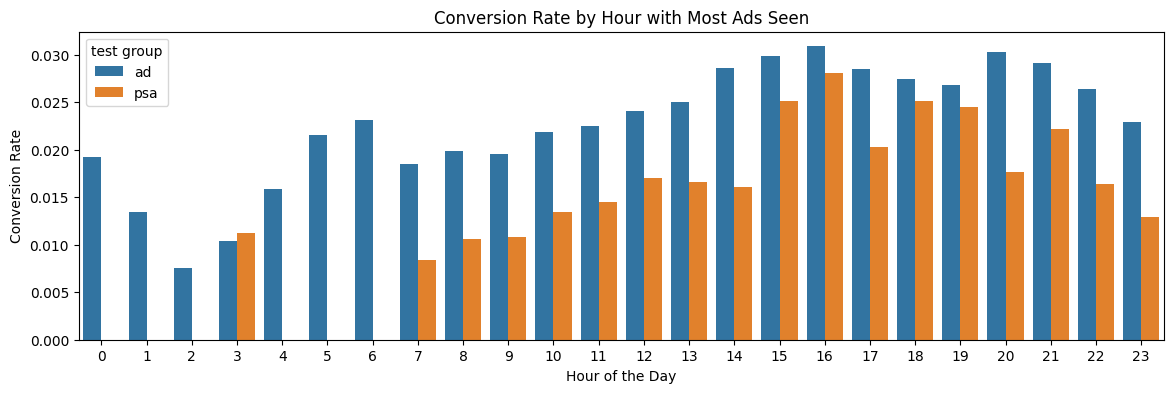

In [158]:
hour_conversion_rate = (
    df.groupby(['most ads hour', 'test group'])['converted']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 4))
sns.barplot(
    data=hour_conversion_rate,
    x='most ads hour',
    y='converted',
    hue='test group'
)

plt.title('Conversion Rate by Hour with Most Ads Seen')
plt.xlabel('Hour of the Day')
plt.ylabel('Conversion Rate')
plt.show()

In [159]:
# Create a contingency table
contingency_table = pd.crosstab(df['converted'], df['test group'])

# Perform Chi-Squared Test
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-Value: {p_chi2:.4f}")
print(f"Degrees of Freedom: {dof}")


Chi-Squared Test Results:
Chi2 Statistic: 54.0058
P-Value: 0.0000
Degrees of Freedom: 1


 The test results provide strong evidence to reject the null hypothesis, meaning that there is a statistically significant relationship between the test group and conversion status.
 
 Given the rejection of the null hypothesis, we can conclude that the ads (as opposed to the PSAs) likely increase the conversion rate.


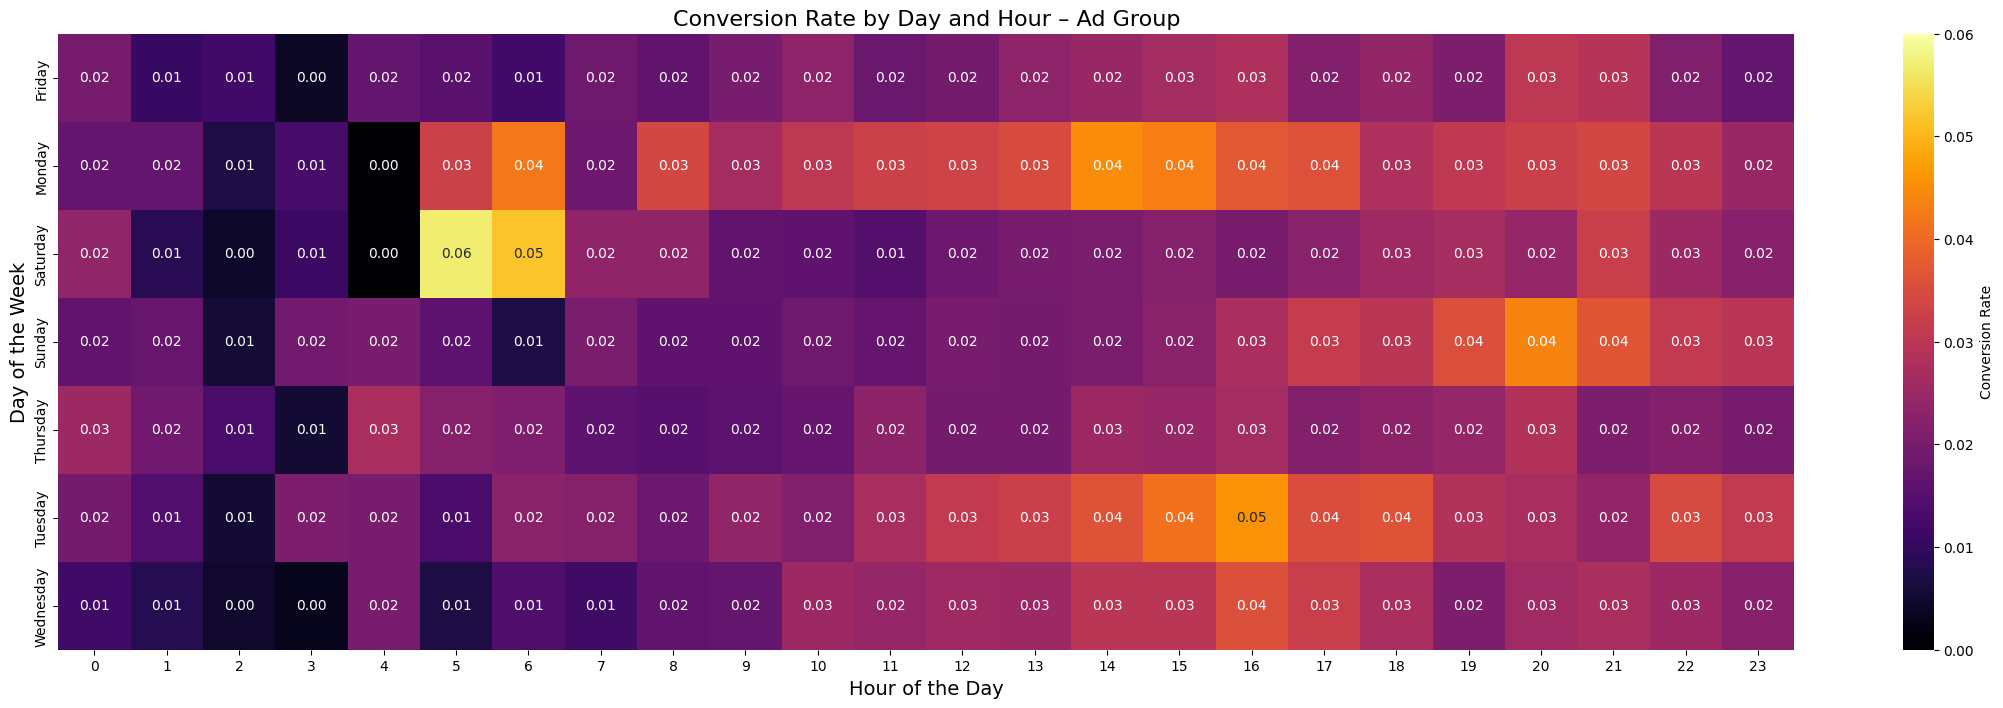

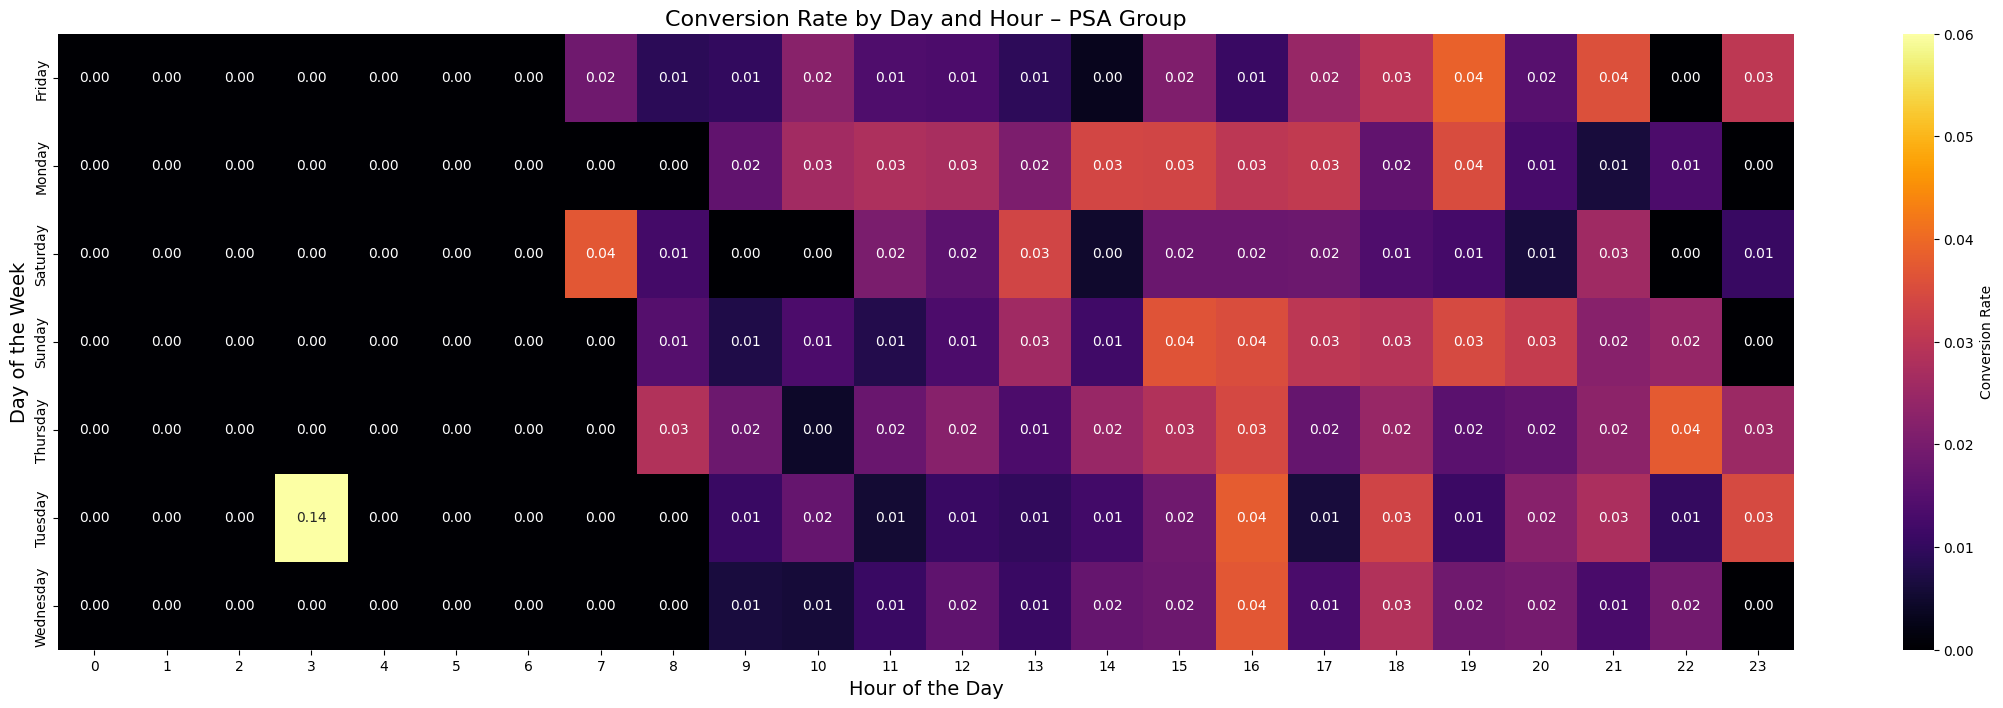

In [160]:
ad_data = df[df['test group'] == "ad"]

ad_pivot = ad_data.pivot_table(
    values='converted',
    index='most ads day',
    columns='most ads hour',
    aggfunc='mean'
)

plt.figure(figsize=(28, 8))
sns.heatmap(
    ad_pivot,
    cmap="inferno",
    vmin=0,
    vmax=0.06,
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Conversion Rate'}
)

plt.title('Conversion Rate by Day and Hour – Ad Group', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Day of the Week', fontsize=14)
plt.show()


psa_data = df[df['test group'] == "psa"]

psa_pivot = psa_data.pivot_table(
    values='converted',
    index='most ads day',
    columns='most ads hour',
    aggfunc='mean'
)

psa_pivot.fillna(0, inplace=True)

plt.figure(figsize=(28, 8))
sns.heatmap(
    psa_pivot,
    cmap="inferno",
    vmin=0,
    vmax=0.06,   # 🔑 misma escala
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Conversion Rate'}
)

plt.title('Conversion Rate by Day and Hour – PSA Group', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Day of the Week', fontsize=14)
plt.show()


#### Logit Model

In [ ]:
df["test group"] = df["test group"].astype("category")
df["most ads day"] = df["most ads day"].astype("category")


df = df.rename(columns={
    "test group": "test_group",
    "most ads day": "most_ads_day",
    "most ads hour": "most_ads_hour"
})

model = smf.logit(
    formula="""
    converted ~ C(test_group, Treatment(reference='psa'))
              + C(most_ads_day)
              + most_ads_hour
    """,
    data=df
).fit()

print(model.summary())





Optimization terminated successfully.
         Current function value: 0.117188
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588092
Method:                           MLE   Df Model:                            8
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                0.005036
Time:                        10:27:57   Log-Likelihood:                -68918.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                2.299e-145
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

In [162]:
(np.exp(model.params[1])-1)*100

np.float64(43.201420028856894)

##### Statistical Interpretation

Coefficient is positive and p-value < 0.001 → significant 

Reject H₀: the ad group has a real and statistically significant effect on conversion compared to psa, controlling for ad exposure, day, and hour.

Holding exposure, day, and hour constant, the ad group has approximately **43% higher odds of conversion than the psa group**.

Confidence Interval does not include 0





#### Conclusions

1. Marketing team should optimize ad frequency and place ads in peak conversion hours. Between 00:00 am and 07:00 am conversion seems to be only possible if there has been an ad.

2. Clients with ads have better conversion rates than psa and days with most ads seen present slightly better conversion rates also. Holding exposure, day, and hour constant, the ad group has approximately **43% higher odds of conversion than the psa group**.

3. Friday is the day where less clients have seen the most ads




